<a href="https://colab.research.google.com/github/saatour/GW170817/blob/main/20260526_Detector_%20toy_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,n_detectors,n_baselines,galaxies_baseline_only,galaxies_baseline_plus_snr
0,3,3,374.000000,374.000000
1,4,6,187.000000,121.460063
2,5,10,112.200000,52.145848
3,6,15,74.800000,26.445794
4,7,21,53.428571,14.990233
5,8,28,40.071429,9.201989
6,9,36,31.166667,5.998028
7,10,45,24.933333,4.096965
8,11,55,20.400000,2.905514
9,12,66,17.000000,2.125000


,n_detectors,n_baselines,galaxies_baseline_only,galaxies_baseline_plus_snr
36,39,741,1.514170,0.032304
37,40,780,1.438462,0.029545
38,41,820,1.368293,0.027082
39,42,861,1.303136,0.024877
40,43,903,1.242525,0.022897
41,44,946,1.186047,0.021116
42,45,990,1.133333,0.019508
43,46,1035,1.084058,0.018055
44,47,1081,1.037928,0.016738
45,48,1128,0.994681,0.015542


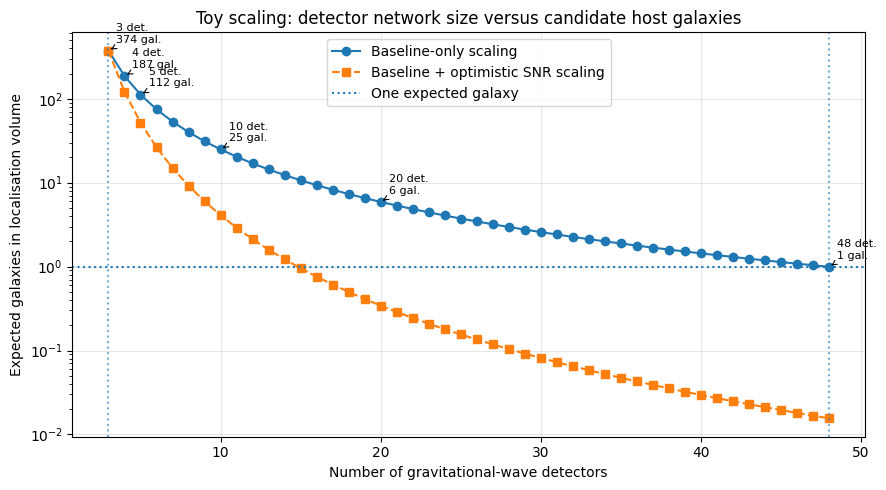

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Toy model: expected number of galaxies versus detector count
# ------------------------------------------------------------
# Reference point:
# From the GW190814-like EAGLE/observed-like volume work:
# ~374 galaxies in a 3-detector GW190814-like localisation volume.

N_ref = 3
galaxies_ref = 374

def n_baselines(N):
    """Number of pairwise baselines for N detectors."""
    return N * (N - 1) / 2

B_ref = n_baselines(N_ref)

# Detector counts to test
N_values = np.arange(3, 49)

# ------------------------------------------------------------
# Model 1: conservative baseline-only scaling
# ------------------------------------------------------------
# Assumption:
#   localisation volume ∝ 1 / number of baselines
#
# Therefore:
#   N_gal(N) = N_gal(3) * B_3 / B_N

galaxies_baseline_only = galaxies_ref * (B_ref / n_baselines(N_values))

# ------------------------------------------------------------
# Model 2: optimistic baseline + network-SNR scaling
# ------------------------------------------------------------
# Assumptions:
#   network SNR ∝ sqrt(N / 3)
#   localisation volume ∝ SNR^(-3)
#   localisation also improves with number of baselines
#
# Therefore:
#   improvement factor =
#       (B_N / B_3) * (N / 3)^(3/2)
#
# This is intentionally optimistic and should not be treated
# as a detector-network forecast.

snr_factor = (N_values / N_ref) ** 0.5

galaxies_baseline_plus_snr = galaxies_ref / (
    (n_baselines(N_values) / B_ref) * snr_factor**3
)

# ------------------------------------------------------------
# Put values into a table
# ------------------------------------------------------------

toy_table = pd.DataFrame({
    "n_detectors": N_values,
    "n_baselines": n_baselines(N_values).astype(int),
    "galaxies_baseline_only": galaxies_baseline_only,
    "galaxies_baseline_plus_snr": galaxies_baseline_plus_snr,
})

display(toy_table.head(15))
display(toy_table.tail(10))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    N_values,
    galaxies_baseline_only,
    marker="o",
    label="Baseline-only scaling"
)

plt.plot(
    N_values,
    galaxies_baseline_plus_snr,
    marker="s",
    linestyle="--",
    label="Baseline + optimistic SNR scaling"
)

# Reference lines
plt.axhline(
    1,
    linestyle=":",
    label="One expected galaxy"
)

plt.axvline(
    3,
    linestyle=":",
    alpha=0.6
)

plt.axvline(
    48,
    linestyle=":",
    alpha=0.6
)

# Annotate key points for baseline-only model
key_points = [3, 4, 5, 10, 20, 48]

for N in key_points:
    y = galaxies_ref * (B_ref / n_baselines(N))
    plt.annotate(
        f"{N} det.\n{y:.0f} gal.",
        xy=(N, y),
        xytext=(N + 0.5, y * 1.25),
        fontsize=8,
        arrowprops=dict(arrowstyle="->", lw=0.8)
    )

plt.yscale("log")
plt.xlabel("Number of gravitational-wave detectors")
plt.ylabel("Expected galaxies in localisation volume")
plt.title("Toy scaling: detector network size versus candidate host galaxies")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

First detector/node count reaching <= 1 expected galaxy:


,snr_uplift,first_n_with_expected_galaxies_leq_1,baselines_at_threshold,expected_galaxies_at_threshold
0,1,48,1128,0.994681
1,2,18,153,0.916667
2,3,10,45,0.923457
3,5,5,10,0.897600
4,10,3,3,0.374000



Expected galaxies for selected detector/node counts:


,k_snr=1,k_snr=2,k_snr=3,k_snr=5,k_snr=10
n_detectors_or_nodes,,,,,
3,374.000000,46.750000,13.851852,2.992000,0.374000
4,187.000000,23.375000,6.925926,1.496000,0.187000
5,112.200000,14.025000,4.155556,0.897600,0.112200
10,24.933333,3.116667,0.923457,0.199467,0.024933
20,5.905263,0.738158,0.218713,0.047242,0.005905
48,0.994681,0.124335,0.036840,0.007957,0.000995


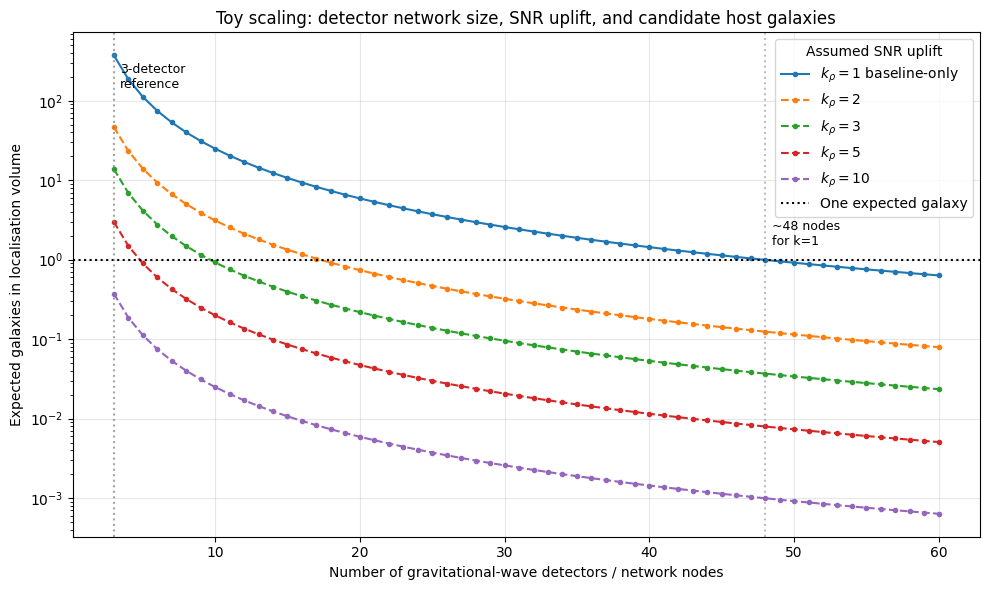

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ------------------------------------------------------------
# Toy model: expected number of galaxies versus detector count
# with different assumed SNR uplift factors
# ------------------------------------------------------------

# Reference point from GW190814-like volume work:
# ~374 observed-like galaxies in a 3-detector localisation volume
N_ref = 3
galaxies_ref = 374

def n_baselines(N):
    """Number of pairwise baselines for N detectors/nodes."""
    return N * (N - 1) / 2

B_ref = n_baselines(N_ref)

# Detector/node counts to explore
N_values = np.arange(3, 61)

# Assumed SNR uplifts relative to GW190814-like reference case
snr_uplifts = [1, 2, 3, 5, 10]

# Optional:
# If True, also assumes that adding more detectors increases network SNR as sqrt(N/3).
# I recommend leaving this False for the cleanest toy model, otherwise you may double-count.
INCLUDE_NETWORK_SNR_FROM_MORE_DETECTORS = False

rows = []

for k_snr in snr_uplifts:
    if INCLUDE_NETWORK_SNR_FROM_MORE_DETECTORS:
        network_snr_factor = np.sqrt(N_values / N_ref)
    else:
        network_snr_factor = np.ones_like(N_values, dtype=float)

    total_snr_factor = k_snr * network_snr_factor

    galaxies_expected = galaxies_ref / (
        (n_baselines(N_values) / B_ref) * total_snr_factor**3
    )

    for N, B, ngal in zip(N_values, n_baselines(N_values), galaxies_expected):
        rows.append({
            "n_detectors_or_nodes": N,
            "n_baselines": int(B),
            "snr_uplift": k_snr,
            "expected_galaxies": ngal,
        })

toy_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Find first detector/node count where expected galaxies <= 1
# ------------------------------------------------------------

threshold_rows = []

for k_snr in snr_uplifts:
    sub = toy_df[toy_df["snr_uplift"] == k_snr].copy()
    below = sub[sub["expected_galaxies"] <= 1]

    if len(below) > 0:
        first = below.iloc[0]
        threshold_rows.append({
            "snr_uplift": k_snr,
            "first_n_with_expected_galaxies_leq_1": int(first["n_detectors_or_nodes"]),
            "baselines_at_threshold": int(first["n_baselines"]),
            "expected_galaxies_at_threshold": first["expected_galaxies"],
        })
    else:
        threshold_rows.append({
            "snr_uplift": k_snr,
            "first_n_with_expected_galaxies_leq_1": np.nan,
            "baselines_at_threshold": np.nan,
            "expected_galaxies_at_threshold": np.nan,
        })

threshold_df = pd.DataFrame(threshold_rows)

print("First detector/node count reaching <= 1 expected galaxy:")
display(threshold_df)

# Show selected values for intuition
selected_N = [3, 4, 5, 10, 20, 48]

selected_table = (
    toy_df[toy_df["n_detectors_or_nodes"].isin(selected_N)]
    .pivot(
        index="n_detectors_or_nodes",
        columns="snr_uplift",
        values="expected_galaxies"
    )
)

selected_table.columns = [f"k_snr={c}" for c in selected_table.columns]

print("\nExpected galaxies for selected detector/node counts:")
display(selected_table)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for k_snr in snr_uplifts:
    sub = toy_df[toy_df["snr_uplift"] == k_snr]

    if k_snr == 1:
        label = r"$k_\rho=1$ baseline-only"
        linestyle = "-"
    else:
        label = fr"$k_\rho={k_snr}$"
        linestyle = "--"

    plt.plot(
        sub["n_detectors_or_nodes"],
        sub["expected_galaxies"],
        marker="o",
        markersize=3,
        linestyle=linestyle,
        label=label
    )

# Reference: one expected galaxy
plt.axhline(
    1,
    linestyle=":",
    color="black",
    linewidth=1.5,
    label="One expected galaxy"
)

# Reference: current 3-detector baseline
plt.axvline(
    3,
    linestyle=":",
    color="gray",
    alpha=0.7
)

plt.text(
    3.4,
    galaxies_ref * 0.8,
    "3-detector\nreference",
    fontsize=9,
    va="top"
)

# Annotate the k=1 threshold around 48 detectors
plt.axvline(
    48,
    linestyle=":",
    color="gray",
    alpha=0.5
)

plt.text(
    48.5,
    1.4,
    "~48 nodes\nfor k=1",
    fontsize=9,
    va="bottom"
)

plt.yscale("log")
plt.xlabel("Number of gravitational-wave detectors / network nodes")
plt.ylabel("Expected galaxies in localisation volume")
plt.title("Toy scaling: detector network size, SNR uplift, and candidate host galaxies")
plt.grid(alpha=0.3)
plt.legend(title="Assumed SNR uplift")

plt.tight_layout()
plt.show()

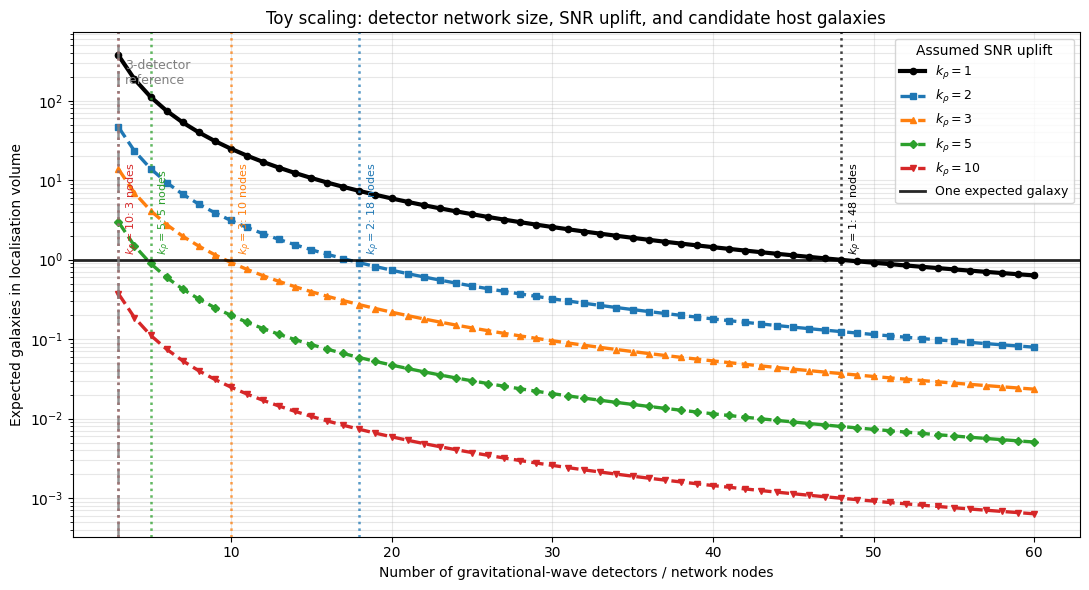

In [2]:
# ------------------------------------------------------------
# Plot: darker curves + one-galaxy threshold lines for each k_snr
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))
ax = plt.gca()

# Darker, high-contrast colours
curve_styles = {
    1:  {"color": "black",      "linewidth": 3.0, "linestyle": "-",  "marker": "o"},
    2:  {"color": "tab:blue",   "linewidth": 2.4, "linestyle": "--", "marker": "s"},
    3:  {"color": "tab:orange", "linewidth": 2.4, "linestyle": "--", "marker": "^"},
    5:  {"color": "tab:green",  "linewidth": 2.4, "linestyle": "--", "marker": "D"},
    10: {"color": "tab:red",    "linewidth": 2.4, "linestyle": "--", "marker": "v"},
}

for k_snr in snr_uplifts:
    sub = toy_df[toy_df["snr_uplift"] == k_snr].copy()
    style = curve_styles[k_snr]

    label = fr"$k_\rho={k_snr}$"

    ax.plot(
        sub["n_detectors_or_nodes"],
        sub["expected_galaxies"],
        color=style["color"],
        linewidth=style["linewidth"],
        linestyle=style["linestyle"],
        marker=style["marker"],
        markersize=4.5,
        label=label
    )

    # Find first detector/node count where expected galaxies <= 1
    below_one = sub[sub["expected_galaxies"] <= 1]

    if len(below_one) > 0:
        first = below_one.iloc[0]
        n_thresh = first["n_detectors_or_nodes"]

        # Vertical threshold line for this curve
        ax.axvline(
            n_thresh,
            color=style["color"],
            linestyle=":",
            linewidth=1.8,
            alpha=0.75
        )

        # Annotation near the one-galaxy line
        ax.text(
            n_thresh + 0.4,
            1.15,
            fr"$k_\rho={k_snr}$: {int(n_thresh)} nodes",
            color=style["color"],
            fontsize=8,
            rotation=90,
            va="bottom",
            ha="left"
        )

# Horizontal one-galaxy threshold
ax.axhline(
    1,
    linestyle="-",
    color="black",
    linewidth=2.0,
    alpha=0.85,
    label="One expected galaxy"
)

# Current 3-detector reference
ax.axvline(
    3,
    linestyle="-.",
    color="gray",
    linewidth=1.8,
    alpha=0.85
)

ax.text(
    3.4,
    galaxies_ref * 0.9,
    "3-detector\nreference",
    fontsize=9,
    color="gray",
    va="top"
)

ax.set_yscale("log")
ax.set_xlabel("Number of gravitational-wave detectors / network nodes")
ax.set_ylabel("Expected galaxies in localisation volume")
ax.set_title("Toy scaling: detector network size, SNR uplift, and candidate host galaxies")

ax.grid(alpha=0.3, which="both")
ax.legend(title="Assumed SNR uplift", fontsize=9)

plt.tight_layout()
plt.show()

First detector-site count reaching <= 1 expected galaxy:


,scenario,k_B,k_Q,first_n_detectors_for_leq_1_galaxy,baselines_at_threshold,expected_galaxies_at_threshold
0,Baseline only,1.0,1.0,48,1128,0.994681
1,Mild geometry gain: $k_B=1.5$,1.5,1.0,33,528,0.944444
2,Mild distance-degeneracy gain: $k_Q=2$,1.0,2.0,34,561,1.000000
3,"Combined moderate gain: $k_B=1.5,\ k_Q=2$",1.5,2.0,23,253,0.985507
4,"Optimistic non-SNR gain: $k_B=2,\ k_Q=3$",2.0,3.0,15,105,0.890476



Expected galaxies for selected detector-site counts:


scenario,Baseline only,"Combined moderate gain: $k_B=1.5,\ k_Q=2$",Mild distance-degeneracy gain: $k_Q=2$,Mild geometry gain: $k_B=1.5$,"Optimistic non-SNR gain: $k_B=2,\ k_Q=3$"
n_detectors,,,,,
3,374.000000,83.111111,187.000000,166.222222,31.166667
4,187.000000,41.555556,93.500000,83.111111,15.583333
5,112.200000,24.933333,56.100000,49.866667,9.350000
10,24.933333,5.540741,12.466667,11.081481,2.077778
20,5.905263,1.312281,2.952632,2.624561,0.492105
30,2.579310,0.573180,1.289655,1.146360,0.214943
40,1.438462,0.319658,0.719231,0.639316,0.119872
48,0.994681,0.221040,0.497340,0.442080,0.082890


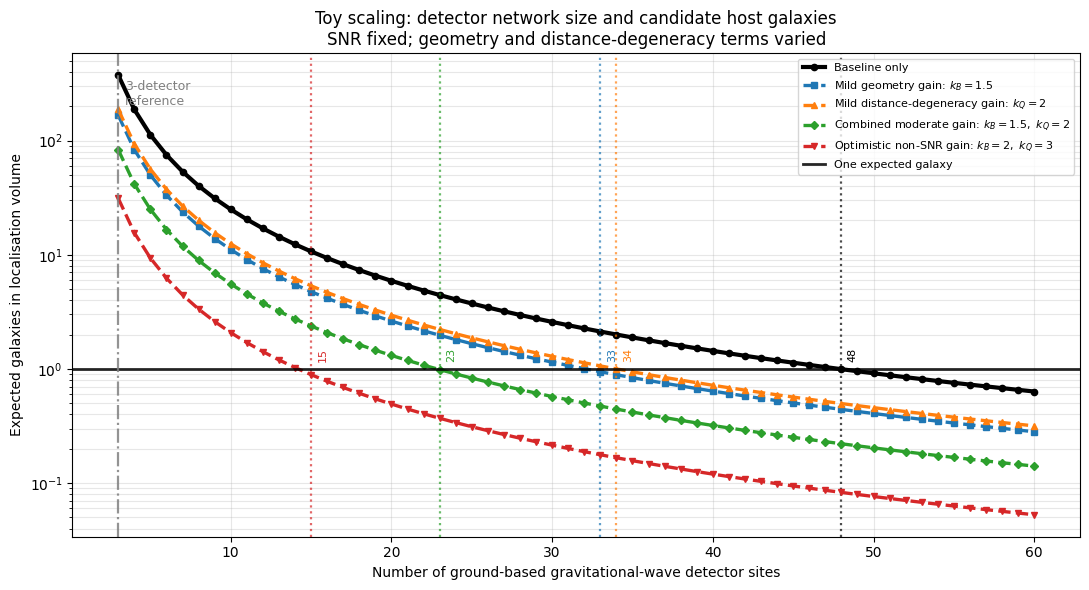

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ============================================================
# Earth-based toy model with geometry + distance-degeneracy terms
# SNR is fixed: k_rho = 1
# ============================================================

# Reference case:
# GW190814-like localisation volume with ~374 observed-like galaxies
N_ref = 3
galaxies_ref = 374

def n_baselines(N):
    """Number of pairwise baselines for N ground-based detector sites."""
    return N * (N - 1) / 2

B_ref = n_baselines(N_ref)

# Detector-site counts to test
N_values = np.arange(3, 61)

# SNR uplift fixed to 1: no SNR improvement
k_rho = 1.0

# ------------------------------------------------------------
# Scenario definitions
# ------------------------------------------------------------
# k_B = effective baseline / sky-geometry improvement factor
# k_Q = distance / inclination / polarisation degeneracy-breaking factor
#
# These are not measured values. They are toy parameters.
#
# Total improvement:
# I_loc = k_rho^3 * k_B^2 * k_G * k_Q

scenarios = [
    {
        "name": "Baseline only",
        "k_B": 1.0,
        "k_Q": 1.0,
        "color": "black",
        "linestyle": "-",
        "linewidth": 3.0,
        "marker": "o",
    },
    {
        "name": r"Mild geometry gain: $k_B=1.5$",
        "k_B": 1.5,
        "k_Q": 1.0,
        "color": "tab:blue",
        "linestyle": "--",
        "linewidth": 2.4,
        "marker": "s",
    },
    {
        "name": r"Mild distance-degeneracy gain: $k_Q=2$",
        "k_B": 1.0,
        "k_Q": 2.0,
        "color": "tab:orange",
        "linestyle": "--",
        "linewidth": 2.4,
        "marker": "^",
    },
    {
        "name": r"Combined moderate gain: $k_B=1.5,\ k_Q=2$",
        "k_B": 1.5,
        "k_Q": 2.0,
        "color": "tab:green",
        "linestyle": "--",
        "linewidth": 2.4,
        "marker": "D",
    },
    {
        "name": r"Optimistic non-SNR gain: $k_B=2,\ k_Q=3$",
        "k_B": 2.0,
        "k_Q": 3.0,
        "color": "tab:red",
        "linestyle": "--",
        "linewidth": 2.4,
        "marker": "v",
    },
]

# ------------------------------------------------------------
# Compute expected galaxy counts
# ------------------------------------------------------------

rows = []

for scenario in scenarios:
    k_B = scenario["k_B"]
    k_Q = scenario["k_Q"]

    for N in N_values:
        B_N = n_baselines(N)
        k_G = B_N / B_ref

        I_loc = (k_rho ** 3) * (k_B ** 2) * k_G * k_Q

        expected_galaxies = galaxies_ref / I_loc

        rows.append({
            "scenario": scenario["name"],
            "n_detectors": N,
            "n_baselines": int(B_N),
            "k_rho": k_rho,
            "k_B": k_B,
            "k_Q": k_Q,
            "k_G": k_G,
            "I_loc": I_loc,
            "expected_galaxies": expected_galaxies,
        })

toy_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Threshold table: first detector count with <= 1 expected galaxy
# ------------------------------------------------------------

threshold_rows = []

for scenario in scenarios:
    name = scenario["name"]
    sub = toy_df[toy_df["scenario"] == name].copy()
    below = sub[sub["expected_galaxies"] <= 1]

    if len(below) > 0:
        first = below.iloc[0]
        threshold_rows.append({
            "scenario": name,
            "k_B": first["k_B"],
            "k_Q": first["k_Q"],
            "first_n_detectors_for_leq_1_galaxy": int(first["n_detectors"]),
            "baselines_at_threshold": int(first["n_baselines"]),
            "expected_galaxies_at_threshold": first["expected_galaxies"],
        })
    else:
        threshold_rows.append({
            "scenario": name,
            "k_B": scenario["k_B"],
            "k_Q": scenario["k_Q"],
            "first_n_detectors_for_leq_1_galaxy": np.nan,
            "baselines_at_threshold": np.nan,
            "expected_galaxies_at_threshold": np.nan,
        })

threshold_df = pd.DataFrame(threshold_rows)

print("First detector-site count reaching <= 1 expected galaxy:")
display(threshold_df)

# ------------------------------------------------------------
# Selected detector counts table
# ------------------------------------------------------------

selected_N = [3, 4, 5, 10, 20, 30, 40, 48]

selected_table = (
    toy_df[toy_df["n_detectors"].isin(selected_N)]
    .pivot(
        index="n_detectors",
        columns="scenario",
        values="expected_galaxies"
    )
)

print("\nExpected galaxies for selected detector-site counts:")
display(selected_table)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))
ax = plt.gca()

for scenario in scenarios:
    name = scenario["name"]
    sub = toy_df[toy_df["scenario"] == name].copy()

    ax.plot(
        sub["n_detectors"],
        sub["expected_galaxies"],
        color=scenario["color"],
        linestyle=scenario["linestyle"],
        linewidth=scenario["linewidth"],
        marker=scenario["marker"],
        markersize=4.5,
        label=name
    )

    # Annotate first <= 1 galaxy threshold
    below_one = sub[sub["expected_galaxies"] <= 1]

    if len(below_one) > 0:
        first = below_one.iloc[0]
        n_thresh = first["n_detectors"]

        ax.axvline(
            n_thresh,
            color=scenario["color"],
            linestyle=":",
            linewidth=1.6,
            alpha=0.7
        )

        ax.text(
            n_thresh + 0.4,
            1.15,
            f"{int(n_thresh)}",
            color=scenario["color"],
            fontsize=8,
            rotation=90,
            va="bottom",
            ha="left"
        )

# One-galaxy line
ax.axhline(
    1,
    color="black",
    linestyle="-",
    linewidth=2.0,
    alpha=0.85,
    label="One expected galaxy"
)

# Reference 3-detector line
ax.axvline(
    3,
    color="gray",
    linestyle="-.",
    linewidth=1.6,
    alpha=0.85
)

ax.text(
    3.4,
    galaxies_ref * 0.9,
    "3-detector\nreference",
    fontsize=9,
    color="gray",
    va="top"
)

ax.set_yscale("log")
ax.set_xlabel("Number of ground-based gravitational-wave detector sites")
ax.set_ylabel("Expected galaxies in localisation volume")
ax.set_title("Toy scaling: detector network size and candidate host galaxies\nSNR fixed; geometry and distance-degeneracy terms varied")

ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()